# Spectrogram
Thurs, Dec 18, 2025

After doing some literature review on "multi-resolution analysis", I think it would be interesting to view the spectrogram of the Green's function. Maybe there's some hidden pattern in the density of states. I think it might give some more info into what frequency and time data is most important to capture.

## Gabor Transform
https://www.youtube.com/watch?v=EfWnEldTyPA

The idea is to do a Fourier transform, but convolve the function with a Gaussian first ($x(t) e^{- \pi (t-\tau)^2}$). The result is a function (aka Gabor transform) that is both a function of time and frequency. You don't have the same time resolution of time-series data, and you also don't have the frequency resolution of a Fourier transform, but you have some resolution in both dimensions.

$$
G_x(\tau, \omega) = \int^{\infty}_{-\infty}x(t) e^{- \pi (t-\tau)^2} e^{-j\omega t}dt
$$

You can change the width of the Gaussian to change the windowing length.

# load data first

In [1]:
# load data
import numpy as np
from quatrex.core.config import parse_config
from pathlib import Path

from scba_container.scba_container import SCBAContainer

simulation_dir = Path("./../../examples/w90/carbon-nanotube/gw")
output_dir = simulation_dir / "outputs"
output_file_prefix = output_dir / "visualize_scba"
archive_dir = simulation_dir / "archive" / "20260226_155038_energy2001_iter5_reduced"
archive_file_prefix = archive_dir / "visualize_scba"

# change these to switch between output and archive
data_files = 'archive'

if data_files == 'output':
    data_file_prefix = output_file_prefix
    config_dir = simulation_dir
elif data_files == 'archive':
    data_file_prefix = archive_file_prefix
    config_dir = archive_dir
else:
    raise ValueError(f"Invalid data_files value: {data_files}. Must be 'output' or 'archive'.")

config = parse_config(config_dir / "quatrex_config.toml")

max_idx = 43823  # total nnz entries - 1
sample_indices = np.load(f"{data_file_prefix}_sample_indices.npy")
num_samples = len(sample_indices)

SCBADataObj = SCBAContainer(
    max_iterations=config.scba.max_iterations,
    energy_window_min=config.electron.energy_window_min,
    energy_window_max=config.electron.energy_window_max,
    energy_window_num=config.electron.energy_window_num,
    num_samples=num_samples,
)

SCBADataObj.load_sample_indices(data_file_prefix)

for i in range(config.scba.max_iterations):
    SCBADataObj.load_g_data(data_file_prefix, iteration=i)
    SCBADataObj.load_p_data(data_file_prefix, iteration=i)
    SCBADataObj.load_w_data(data_file_prefix, iteration=i)
    SCBADataObj.load_sigma_data(data_file_prefix, iteration=i)

# === user parameters ===
iteration = 3
sample_idx = 86

assert (
    sample_idx <= num_samples
), f"sample_idx={sample_idx} exceeds num_samples={num_samples}"
nnz_index = SCBADataObj.sample_indices[sample_idx]

g_lesser = SCBADataObj.g_lesser[iteration, :, sample_idx]
g_greater = SCBADataObj.g_greater[iteration, :, sample_idx]
p_lesser = SCBADataObj.p_lesser[iteration, :, sample_idx]
p_greater = SCBADataObj.p_greater[iteration, :, sample_idx]

/scratch/yongli/document/github/quatrex/src/qttools/__init__.py:56: UserWarning: 'cupy' is unavailable or not working, defaulting to 'numpy'. (No module named 'cupy')
  warnings.warn(
/scratch/yongli/document/github/quatrex/src/quatrex/core/config.py:933: UserWarning: The CPU code will run sequentially which may impact performance.
  warnings.warn(


# SciPy Spectrogram
Unfortunately, the `scipy.signal.spectrogram` [function is considered legacy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html). We'll use ths [short-time FFT to produce the spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.ShortTimeFFT.spectrogram.html#scipy.signal.ShortTimeFFT.spectrogram), which is the new recommended way. It's just the square of the short-time FFT, to ensure that the output is always positive. We choose the window function to be a Gaussian.

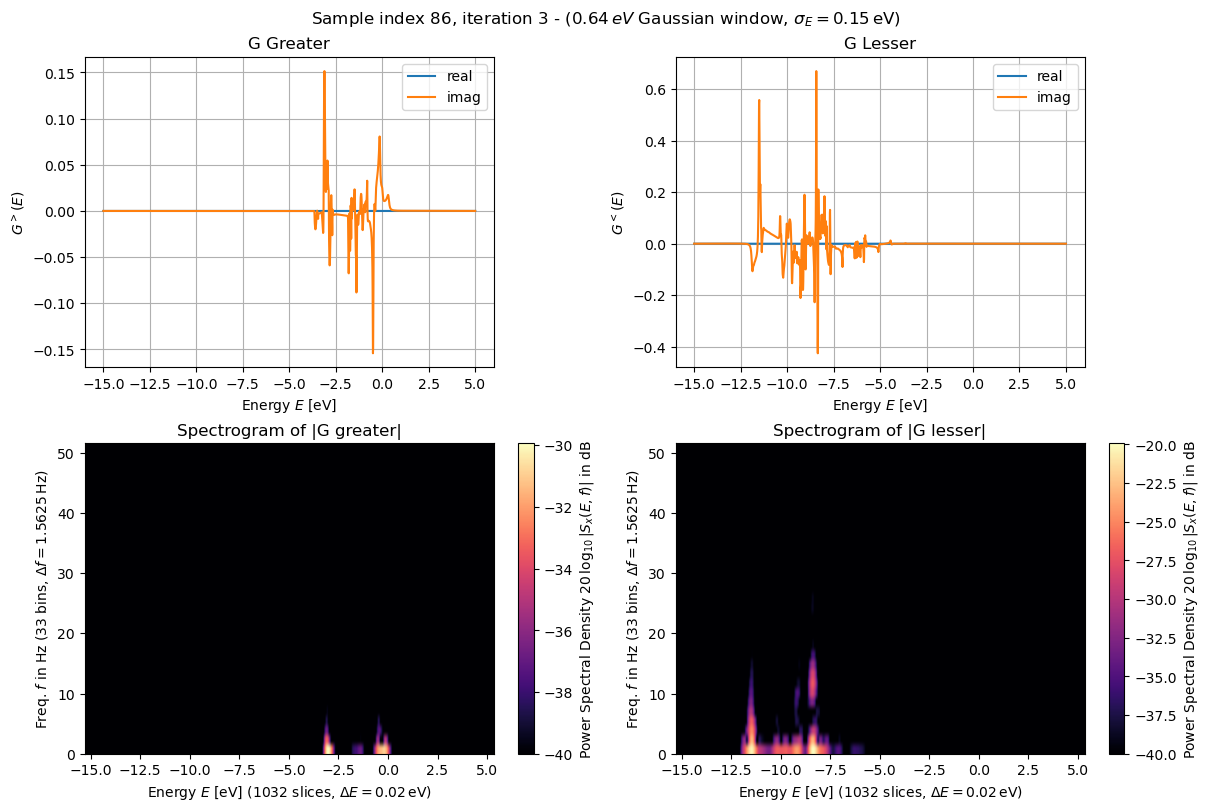

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import gaussian

dE = np.abs(
    SCBADataObj.energies[1] - SCBADataObj.energies[0]
)  # sampling interval in time domain corresponding to energy grid spacing
N = len(SCBADataObj.energies)

# user parameters for spectrogram
g_std = 15  # standard deviation for Gaussian window in samples
g_M = 64  # window length in samples

win = gaussian(g_M, std=g_std, sym=True)  # symmetric Gaussian window
SFT = ShortTimeFFT(win, hop=2, fs=1 / dE, scale_to="psd")

Sx_greater = SFT.spectrogram(np.abs(g_greater))  # calculate absolute square of STFT
Sx_lesser = SFT.spectrogram(np.abs(g_lesser))  # calculate absolute square of STFT

# region: === plotting ===
fig, axs = plt.subplots(
    2, 2, figsize=(12, 8), layout="constrained"
)  # constrained layout to lineup the x-axis

axs[0, 0].set_title(f"G Greater")
axs[0, 0].plot(SCBADataObj.energies, np.real(g_greater), label="real")
axs[0, 0].plot(SCBADataObj.energies, np.imag(g_greater), label="imag")
axs[0, 0].set(xlabel="Energy $E$ [eV]", ylabel=r"$G^{>}(E)$")
axs[0, 0].legend()
axs[0, 0].grid()

axs[0, 1].set_title(f"G Lesser")
axs[0, 1].plot(SCBADataObj.energies, np.real(g_lesser), label="real")
axs[0, 1].plot(SCBADataObj.energies, np.imag(g_lesser), label="imag")
axs[0, 1].set(xlabel="Energy $E$ [eV]", ylabel=r"$G^{<}(E)$")
axs[0, 1].legend()
axs[0, 1].grid()


t_lo, t_hi, f_lo, f_hi = SFT.extent(N)
t_lo += SCBADataObj.energies[0]
t_hi += SCBADataObj.energies[0]

axs[1, 0].set_title(f"Spectrogram of |G greater|")
axs[1, 0].set(
    xlabel=f"Energy $E$ [eV] ({SFT.p_num(N)} slices, "
    + rf"$\Delta E = {SFT.delta_t:g}\,$eV)",
    ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, "
    + rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
    xlim=(t_lo, t_hi),
)
Sx_dB = 10 * np.log10(np.fmax(Sx_greater, 1e-4))  # limit range to -40 dB
im1 = axs[1, 0].imshow(
    Sx_dB, origin="lower", aspect="auto", extent=(t_lo, t_hi, f_lo, f_hi), cmap="magma"
)
fig.colorbar(im1, label="Power Spectral Density " + r"$20\,\log_{10}|S_x(E, f)|$ in dB")

axs[1, 1].set_title(f"Spectrogram of |G lesser|")
axs[1, 1].set(
    xlabel=f"Energy $E$ [eV] ({SFT.p_num(N)} slices, "
    + rf"$\Delta E = {SFT.delta_t:g}\,$eV)",
    ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, "
    + rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
    xlim=(t_lo, t_hi),
)
Sx_dB = 10 * np.log10(np.fmax(Sx_lesser, 1e-4))  # limit range to -40 dB
im2 = axs[1, 1].imshow(
    Sx_dB, origin="lower", aspect="auto", extent=(t_lo, t_hi, f_lo, f_hi), cmap="magma"
)
fig.colorbar(im2, label="Power Spectral Density " + r"$20\,\log_{10}|S_x(E, f)|$ in dB")

plt.suptitle(
    rf"Sample index {sample_idx}, iteration {iteration} - ({SFT.m_num*SFT.T:g}$\,eV$ Gaussian "
    + rf"window, $\sigma_E={g_std*SFT.T:g}\,$eV)"
)
plt.show()
# endregion

# reference code from scipy
https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.ShortTimeFFT.spectrogram.html#scipy.signal.ShortTimeFFT.spectrogram

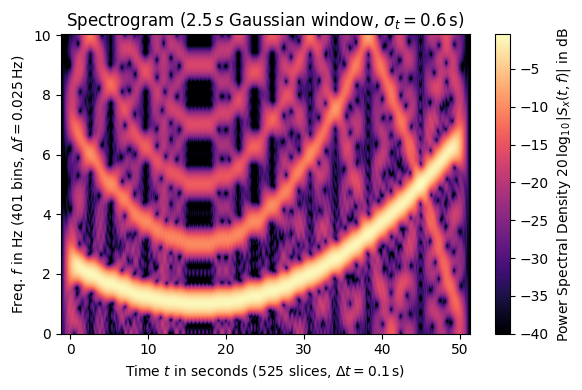

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import gaussian

T_x, N = 1 / 20, 1000  # 20 Hz sampling rate for 50 s signal
t_x = np.arange(N) * T_x  # time indexes for signal
f_i = 5e-3 * (t_x - t_x[N // 3]) ** 2 + 1  # varying frequency
x = square(2 * np.pi * np.cumsum(f_i) * T_x)  # the signal
g_std = 12  # standard deviation for Gaussian window in samples
win = gaussian(50, std=g_std, sym=True)  # symmetric Gaussian wind.
SFT = ShortTimeFFT(win, hop=2, fs=1 / T_x, mfft=800, scale_to="psd")
Sx2 = SFT.spectrogram(x)  # calculate absolute square of STFT
fig1, ax1 = plt.subplots(figsize=(6.0, 4.0))  # enlarge plot a bit
t_lo, t_hi = SFT.extent(N)[:2]  # time range of plot
ax1.set_title(
    rf"Spectrogram ({SFT.m_num*SFT.T:g}$\,s$ Gaussian "
    + rf"window, $\sigma_t={g_std*SFT.T:g}\,$s)"
)
ax1.set(
    xlabel=f"Time $t$ in seconds ({SFT.p_num(N)} slices, "
    + rf"$\Delta t = {SFT.delta_t:g}\,$s)",
    ylabel=f"Freq. $f$ in Hz ({SFT.f_pts} bins, "
    + rf"$\Delta f = {SFT.delta_f:g}\,$Hz)",
    xlim=(t_lo, t_hi),
)
Sx_dB = 10 * np.log10(np.fmax(Sx2, 1e-4))  # limit range to -40 dB
im1 = ax1.imshow(
    Sx_dB, origin="lower", aspect="auto", extent=SFT.extent(N), cmap="magma"
)
# ax1.plot(t_x, f_i, 'g--', alpha=.5, label='$f_i(t)$')
fig1.colorbar(
    im1, label="Power Spectral Density " + r"$20\,\log_{10}|S_x(t, f)|$ in dB"
)
# Shade areas where window slices stick out to the side:
# for t0_, t1_ in [(t_lo, SFT.lower_border_end[0] * SFT.T),
#                  (SFT.upper_border_begin(N)[0] * SFT.T, t_hi)]:
#     ax1.axvspan(t0_, t1_, color='w', linewidth=0, alpha=.3)
# for t_ in [0, N * SFT.T]:  # mark signal borders with vertical line
#     ax1.axvline(t_, color='c', linestyle='--', alpha=0.5)
# ax1.legend()
fig1.tight_layout()
plt.show()